In [1]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor, Compose, Resize
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import random

# Define custom Dataset class for image pairs
class ImagePairDataset(Dataset):
    def __init__(self, ground_truth_dir, transform=None, noise_level=0.1):
        self.ground_truth_dir = ground_truth_dir
        self.ground_truth_images = sorted(os.listdir(ground_truth_dir))
        self.transform = transform
        self.noise_level = noise_level

    def __len__(self):
        return len(self.ground_truth_images)

    def __getitem__(self, idx):
        ground_truth_path = os.path.join(self.ground_truth_dir, self.ground_truth_images[idx])
        ground_truth_image = Image.open(ground_truth_path).convert("L")

        if self.transform:
            ground_truth_image = self.transform(ground_truth_image)
        
        # Add noise to the ground truth image to create the noisy image
        noisy_image = ground_truth_image + torch.randn_like(ground_truth_image) * self.noise_level
        
        return noisy_image, ground_truth_image

# Transform for images
transform = Compose([
    Resize((512, 512)),
    ToTensor()
])

# Dataset paths
ground_truth_dir = r"C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\outputs\RawDataQA (3)\aligned_self_fused_images"

# Create the dataset and dataloader
dataset = ImagePairDataset(ground_truth_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Load model and diffusion classes
from DDPM_Net import Model
from DDPM_GaussianDiffusion import GaussianDiffusion, get_beta_schedule

def noise_estimation_loss(model, x0, t, e, b, device):
    a = torch.cumprod(1-b, dim=0).index_select(0, t).view(-1, 1, 1, 1).to(device)
    x = x0 * a.sqrt() + e * (1.0 - a).sqrt()
    output = model(x, t.float())
    return (e - output).square().sum(dim=(1, 2, 3)).mean(dim=0)

def model_predict(model, x0, betas, t, T, device):
    with torch.no_grad():
        a = torch.cumprod(1 - betas, dim=0)
        a_t = a[t].to(device)
        e = torch.randn_like(x0).to(device)
        xt = torch.sqrt(1 - a_t) * e + torch.sqrt(a_t) * x0
        pred_e = model(xt, torch.tensor([T], device=device).float())
        x0_pred = 1 / torch.sqrt(a_t) * xt - torch.sqrt(1 - a_t) / torch.sqrt(a_t) * pred_e
        return x0_pred, xt



c:\Users\CL-11\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


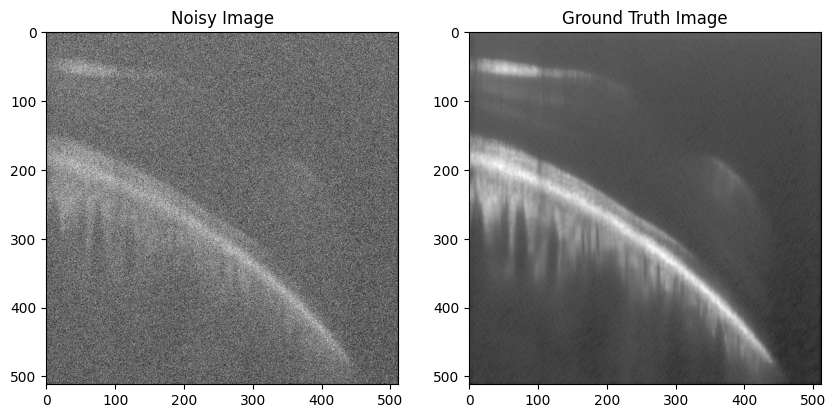

In [2]:
# Get a pair of images
noisy_image, ground_truth_image = dataset[0]  # Change index as needed

# Convert tensors to numpy arrays and squeeze to remove single-dimensional entries
noisy_image = noisy_image.numpy().squeeze()
ground_truth_image = ground_truth_image.numpy().squeeze()

# Plot the images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(noisy_image, cmap='gray')
plt.title('Noisy Image')

plt.subplot(1, 2, 2)
plt.imshow(ground_truth_image, cmap='gray')
plt.title('Ground Truth Image')

plt.show()

Loaded pre-trained model from C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\ckpts\DDPM_oct_dataset2_2021-07-08.pt


Epoch 1/50:   0%|          | 0/89 [00:00<?, ?it/s]c:\Users\CL-11\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
Epoch 1/50: 100%|██████████| 89/89 [03:25<00:00,  2.30s/it, loss=4.42e+4]

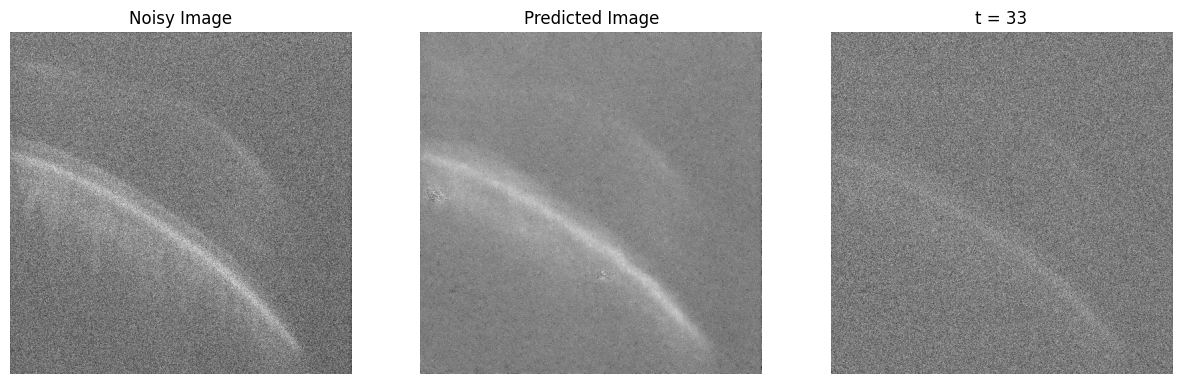

Epoch 2/50: 100%|██████████| 89/89 [03:21<00:00,  2.23s/it, loss=3.34e+4]

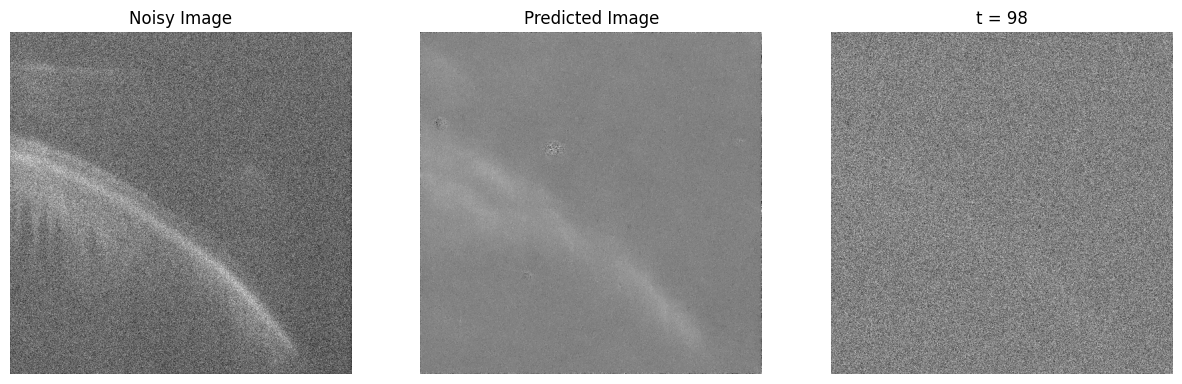

Epoch 3/50: 100%|██████████| 89/89 [03:17<00:00,  2.20s/it, loss=4.13e+4]

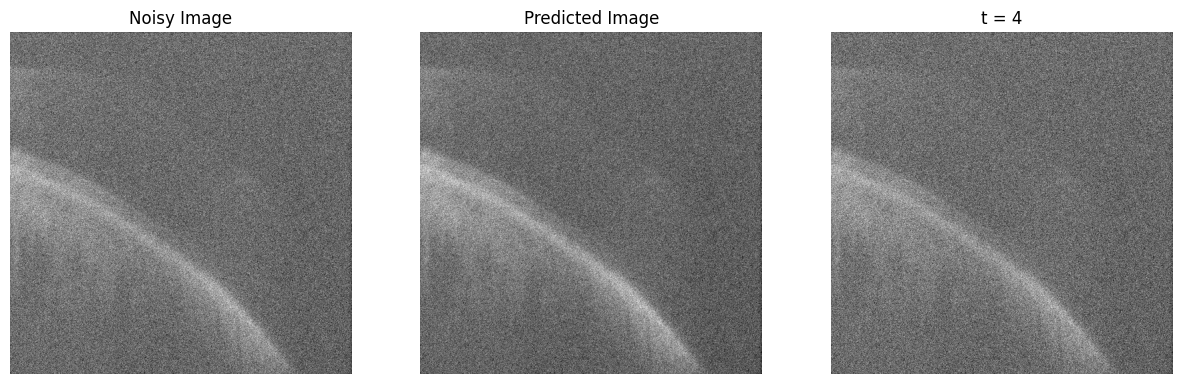

Epoch 3/50: 100%|██████████| 89/89 [03:18<00:00,  2.23s/it, loss=4.13e+4]


Checkpoint saved: C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\ckpts\DDPM_finetuned_epoch_3.pt


Epoch 4/50: 100%|██████████| 89/89 [03:19<00:00,  2.25s/it, loss=3.48e+4]

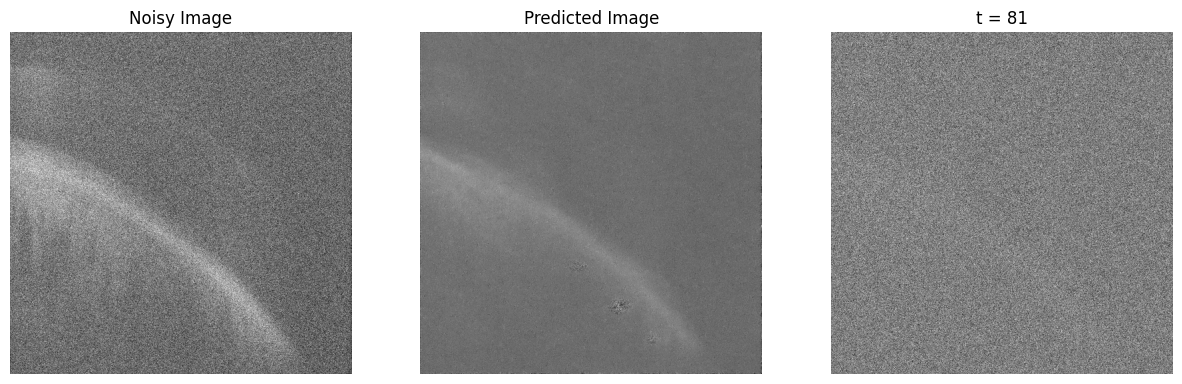

Epoch 5/50:  20%|██        | 18/89 [00:41<02:42,  2.29s/it, loss=2.91e+4]

In [3]:
# Initialize the model, optimizer, and loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model().to(device)

# Load pre-trained model if available
#checkpoint_path = r'C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\ckpts\DDPM_finetuned_epoch_6.pt'
checkpoint_path = r"C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\ckpts\DDPM_oct_dataset2_2021-07-08.pt"
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"Loaded pre-trained model from {checkpoint_path}")

# Set up diffusion parameters
T = 100
betas = get_beta_schedule('linear', beta_start=0.0001, beta_end=0.02, num_diffusion_timesteps=T)
betas = torch.from_numpy(betas).float().to(device)
diffusion = GaussianDiffusion(betas=betas, device=device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

# Fine-tuning loop
n_epoch = 50
save_interval = 3  # Save checkpoint every 3 epochs
output_dir = r"C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\ckpts"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for epoch in range(n_epoch):
    model.train()
    running_loss = 0.0
    with tqdm(total=len(dataloader), desc=f"Epoch {epoch + 1}/{n_epoch}") as pbar:
        for step, (noisy, ground_truth) in enumerate(dataloader):
            noisy = noisy.to(device)
            ground_truth = ground_truth.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass through the model and the diffusion process
            n = noisy.size(0)
            t = torch.randint(0, T, (n,), device=device).long()
            e = torch.randn_like(noisy).to(device)
            loss = noise_estimation_loss(model, noisy, t, e, betas, device)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            pbar.set_postfix(loss=running_loss / (step + 1))
            pbar.update(1)

            if step % (len(dataloader) - 1) == 0 and step != 0:
                timestep = random.randint(1, T-1)
                x0_pred, xt = model_predict(model, noisy, betas, timestep, T, device)
                
                plt.figure(figsize=(15, 6))
                plt.subplot(1, 3, 1)
                plt.imshow(noisy[0, 0].cpu().numpy(), cmap='gray')
                plt.axis('off')
                plt.title('Noisy Image')
                
                plt.subplot(1, 3, 2)
                plt.imshow(x0_pred[0, 0].cpu().numpy(), cmap='gray')
                plt.axis('off')
                plt.title('Predicted Image')
                
                plt.subplot(1, 3, 3)
                plt.imshow(xt[0, 0].cpu().numpy(), cmap='gray')
                plt.axis('off')
                plt.title(f't = {timestep}')
                
                plt.show()
    
    # Save checkpoint
    if (epoch + 1) % save_interval == 0:
        checkpoint_name = f"DDPM_finetuned_epoch_{epoch + 1}.pt"
        checkpoint_path = os.path.join(output_dir, checkpoint_name)
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")
    scheduler.step()

# Save the final model
final_model_path = os.path.join(output_dir, "DDPM_finetuned_final.pt")
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved: {final_model_path}")


In [ ]:
import os
import torch
from PIL import Image
from torchvision.transforms import ToTensor, Compose, Resize
import matplotlib.pyplot as plt
from DDPM_Net import Model
from DDPM_GaussianDiffusion import GaussianDiffusion, get_beta_schedule

# Transform for images
transform = Compose([
    Resize((512, 512)),
    ToTensor()
])

# Function to load a single image and transform it
def load_image(image_path, transform):
    image = Image.open(image_path).convert("L")
    image = transform(image)
    return image.unsqueeze(0)  # Add batch dimension

# Paths
noisy_image_path = r'C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\outputs\RawDataQA (3)\cropped_base_images\RawDataQA3 (3).tiff'
ground_truth_image_path = r"C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\outputs\RawDataQA (3)\aligned_self_fused_images\RawDataQA3 (3).tiff"
checkpoint_path = r'C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\ckpts\DDPM_finetuned_final.pt'

# Load images
noisy_image = load_image(noisy_image_path, transform)
ground_truth_image = load_image(ground_truth_image_path, transform)

# Initialize the model and diffusion class
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model().to(device)

# Load the pre-trained model
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()  # Set model to evaluation mode

# Set up diffusion parameters
T = 100
betas = get_beta_schedule('linear', beta_start=0.0001, beta_end=0.02, num_diffusion_timesteps=T)
betas = torch.from_numpy(betas).float().to(device)
diffusion = GaussianDiffusion(betas=betas, device=device)

# Perform prediction
with torch.no_grad():
    noisy_image = noisy_image.to(device)
    ground_truth_image = ground_truth_image.to(device)

    # Forward pass through the model and the diffusion process
    t = torch.tensor([T // 2], device=device).long()  # Using a middle timestep for prediction
    noisy_diffused = diffusion.diffuse(noisy_image, t)
    eps = torch.randn_like(noisy_diffused)
    predicted_image = model(noisy_diffused, t.float())

# Convert tensors to numpy arrays for visualization
noisy_image_np = noisy_image.squeeze().cpu().numpy()
ground_truth_image_np = ground_truth_image.squeeze().cpu().numpy()
predicted_image_np = predicted_image.squeeze().cpu().numpy()

# Plot the images
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(noisy_image_np, cmap='gray')
plt.axis('off')
plt.title('Noisy Image')

plt.subplot(1, 3, 2)
plt.imshow(predicted_image_np, cmap='gray')
plt.axis('off')
plt.title('Predicted Image')

plt.subplot(1, 3, 3)
plt.imshow(ground_truth_image_np, cmap='gray')
plt.axis('off')
plt.title('Ground Truth Image')

plt.show()
